In [133]:
# **Rent VS Salary Analysis**

In [1]:
import requests
import pandas as pd

print("Libraries loaded successfully")

Libraries loaded successfully


In [1]:
#reading and exploration

In [135]:
# **TASK1. SALARY - FINDING MONTHLY TAKE HOME PER TARGETED CITIES**

In [2]:
## load data from jobbank.csv file -- wage report
jobbank = pd.read_csv("jobbank.csv")

## printing top 5 rows
jobbank.head()


,NOC_CNP,NOC_Title_eng,NOC_Title_fra,prov,ER_Code_Code_RE,ER_Name,Nom_RE,Low_Wage_Salaire_Minium,Median_Wage_Salaire_Median,High_Wage_Salaire_Maximal,...,Quartile3_Wage_Salaire_Quartile3,Source2025_NHQ,Data_Source_E,Data_Source_F,Reference_Period,Revision_Date_Date_revision,Annual_Wage_Flag_Salaire_annuel,Wage_Comment_E,Wage_Comment_F,EmployeesWithNonWageBenefit_Pct
0,NOC_00010,Legislators,Membres des corps législatifs,NAT,ER00,Canada,Canada,32867.0,84000.0,184000.0,...,132000.0,Census 2021 CAN NOC5,2021 Census,Recensement 2021,2021,2025-11-19,1,Wages for this occupation are presented at an ...,Pour cette profession sont présentés au taux a...,63.1
1,NOC_00010,Legislators,Membres des corps législatifs,NL,ER10,Newfoundland and Labrador,Terre-Neuve-et-Labrador,NaN,99000.0,NaN,...,NaN,Census 2021 PR NOC5,2021 Census,Recensement 2021,2021,2025-11-19,1,Wages for this occupation are presented at an ...,Pour cette profession sont présentés au taux a...,NaN
2,NOC_00010,Legislators,Membres des corps législatifs,NL,ER1010,Avalon Peninsula,Avalon Peninsula,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2025-11-19,0,"Due to data limitations, the wage for this occ...","En raison des limites associées aux données, l...",NaN
3,NOC_00010,Legislators,Membres des corps législatifs,NL,ER1020,South Coast--Burin Peninsula,Côte-sud--Burin Peninsula,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2025-11-19,0,"Due to data limitations, the wage for this occ...","En raison des limites associées aux données, l...",NaN
4,NOC_00010,Legislators,Membres des corps législatifs,NL,ER1030,West Coast--Northern Peninsula--Labrador,Côte-ouest--Northern Peninsula--Labrador,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2025-11-19,0,"Due to data limitations, the wage for this occ...","En raison des limites associées aux données, l...",NaN


In [3]:
# ** Wages csv file is  --checking NOC CODES  in data sets**

# Filter for NOC 21223 (Data analyst - informatics and systems)
noc_21223 = jobbank[jobbank['NOC_CNP'] == 'NOC_21223']

print(f"\nNumber of rows for NOC 21223: {len(noc_21223)}")

print("\n" + "="*40 + "\n")

# checking city names
print(noc_21223['ER_Name'].unique())

print("\n" + "="*40 + "\n")

# checking duplicates
print(f"\nThe sum of duplicate(s) is: {noc_21223.duplicated().sum()}")

print("\n" + "="*40 + "\n")

# checking the null values

null_counts = noc_21223.isnull().sum()

print("\033[1m" + "\nColumns with missing values:" + "\033[0m")

print(null_counts[null_counts > 0])


Number of rows for NOC 21223: 86


['Canada' 'Newfoundland and Labrador' 'Avalon Peninsula'
 'South Coast--Burin Peninsula' 'West Coast--Northern Peninsula--Labrador'
 'Notre Dame--Central Bonavista Bay' 'Prince Edward Island' 'Nova Scotia'
 'Cape Breton' 'North Shore' 'Annapolis Valley' 'Southern' 'Halifax'
 'New Brunswick' 'Campbellton--Miramichi' 'Moncton--Richibucto'
 'Saint John--St. Stephen' 'Fredericton--Oromocto' 'Edmundston--Woodstock'
 'Quebec' 'Gaspésie--Îles-de-la-Madeleine' 'Bas-Saint-Laurent'
 'Capitale-Nationale' 'Chaudière-Appalaches' 'Estrie' 'Centre-du-Québec'
 'Montérégie' 'Montréal' 'Laval' 'Lanaudière' 'Laurentides' 'Outaouais'
 'Abitibi-Témiscamingue' 'Mauricie' 'Saguenay--Lac-Saint-Jean' 'Côte-Nord'
 'Nord-du-Québec' 'Ontario' 'Ottawa' 'Kingston--Pembroke'
 'Muskoka--Kawarthas' 'Toronto' 'Kitchener--Waterloo--Barrie'
 'Hamilton--Niagara Peninsula' 'London' 'Windsor--Sarnia'
 'Stratford--Bruce Peninsula' 'Northeast' 'Northwest' 'Manitoba'
 'Southeast' 'South Cent

In [4]:
# checking data for targeted arrea only

#list of the cities all lower case
target_cities = ['lower mainland', 'toronto', 'ottawa', 'calgary', 'montréal']

# Converting the column to lower and checking if it exists in list
jobbank_target_cities = noc_21223[noc_21223["ER_Name"].str.lower().isin(target_cities)]

counts = 1
for city in jobbank_target_cities["ER_Name"]:
    print(f"\nCount {counts}: {city}")
    counts +=1


Count 1: Montréal

Count 2: Ottawa

Count 3: Toronto

Count 4: Calgary

Count 5: Lower Mainland


In [11]:
# independent copy to work on
jobbank_summary = jobbank_target_cities.copy()

# Renaming cities to match rental data
rename_map = {
    'Montréal': 'Montreal',
    'Ottawa': 'Ottawa',
    'Toronto': 'Toronto',
    'Calgary': 'Calgary',
    'Lower Mainland': 'Vancouver'
}
jobbank_summary['City'] = jobbank_summary['ER_Name'].replace(rename_map)

jobbank_summary[['City', 'Low_Wage_Salaire_Minium']].head()

,City,Low_Wage_Salaire_Minium
7509,Montreal,27.21
7520,Ottawa,24.73
7523,Toronto,21.90
7550,Calgary,28.57
7558,Vancouver,32.08


In [12]:
# finding yearly median_wage per city

#anual calculations to the columns
# Annual = Hourly * 40hrs * 52weeks
jobbank_summary['Annual_Salary'] = jobbank_summary['Low_Wage_Salaire_Minium'] * 40 * 52

# Monthly Take-home = (Annual * 75% for tax) / 12 months
jobbank_summary['Monthly_Takehome'] = ((jobbank_summary['Annual_Salary'] * 0.73) / 12).round(2)

wage_summary = jobbank_summary[['City', 'Low_Wage_Salaire_Minium', 'Annual_Salary', 'Monthly_Takehome']]

wage_summary.head()

,City,Low_Wage_Salaire_Minium,Annual_Salary,Monthly_Takehome
7509,Montreal,27.21,56596.8,3442.97
7520,Ottawa,24.73,51438.4,3129.17
7523,Toronto,21.90,45552.0,2771.08
7550,Calgary,28.57,59425.6,3615.06
7558,Vancouver,32.08,66726.4,4059.19


In [10]:
# **TASK2. Finding rent prices per one bedroom appt

In [14]:
#Examining file structure stacan.csv file -- statcan file has metadata
with open("statcan.csv", "r", encoding='utf-8-sig') as file:
    lines = file.readlines()
    for i in range(min(20, len(lines))):
        print(f"Line {i}: {repr(lines[i][:100])}")

Line 0: '"Asking rent prices, by rental unit type and number of bedrooms, experimental estimates 1"\n'
Line 1: '"Frequency:\xa0Quarterly"\n'
Line 2: '"Table: 46-10-0092-01"\n'
Line 3: '"Release date: 2026-03-11"\n'
Line 4: '"Geography: Census metropolitan area, Census metropolitan area part"\n'
Line 5: '""\n'
Line 6: '""\n'
Line 7: '\n'
Line 8: ',"Estimates","Average asking rent",,,,\n'
Line 9: '"Geography","Rental unit type","Q4 2024","Q1 2025","Q2 2025","Q3 2025","Q4 2025"\n'
Line 10: ',,"Dollars",,,,\n'
Line 11: '"Montréal, Census metropolitan area (CMA)","House - 3 or more bedrooms","2,900","2,890","2,830E","2,'
Line 12: ',"Apartment - 1 bedroom","1,550","1,540","1,530E","1,550","1,550"\n'
Line 13: ',"Apartment - 2 bedrooms","1,930","1,930","1,920E","1,930","1,920"\n'
Line 14: ',"Room","720","710","720E","720","710"\n'
Line 15: '"Ottawa - Gatineau (Quebec part), Census metropolitan area (CMA)","House - 3 or more bedrooms","2,31'
Line 16: ',"Apartment - 1 bedroom","1,580","1,520","1

In [15]:
#loading statcan file
#actual data headers start at line 9

rental_data = pd.read_csv(
    'statcan.csv',
    skiprows=9,
    encoding='utf-8-sig'
)

rental_data.head(30)

,Geography,Rental unit type,Q4 2024,Q1 2025,Q2 2025,Q3 2025,Q4 2025
0,NaN,NaN,Dollars,NaN,NaN,NaN,NaN
1,"Montréal, Census metropolitan area (CMA)",House - 3 or more bedrooms,"2,900","2,890","2,830E","2,760","2,760"
2,NaN,Apartment - 1 bedroom,"1,550","1,540","1,530E","1,550","1,550"
3,NaN,Apartment - 2 bedrooms,"1,930","1,930","1,920E","1,930","1,920"
4,NaN,Room,720,710,720E,720,710
5,"Ottawa - Gatineau (Quebec part), Census metrop...",House - 3 or more bedrooms,"2,310","2,330","2,380E","2,430","2,430"
6,NaN,Apartment - 1 bedroom,"1,580","1,520","1,490E","1,460","1,450"
7,NaN,Apartment - 2 bedrooms,"1,770","1,680E",F,"1,730","1,660"
8,NaN,Room,750,720,730E,730,700
9,"Ottawa - Gatineau (Ontario part), Census metro...",House - 3 or more bedrooms,"2,960","2,990","3,000E","3,000","2,930"


In [16]:
# Forward fill the Geography column (empty cells belong to the city above)
rental_data['Geography'] = rental_data['Geography'].ffill()

rental_data.head(30)

,Geography,Rental unit type,Q4 2024,Q1 2025,Q2 2025,Q3 2025,Q4 2025
0,NaN,NaN,Dollars,NaN,NaN,NaN,NaN
1,"Montréal, Census metropolitan area (CMA)",House - 3 or more bedrooms,"2,900","2,890","2,830E","2,760","2,760"
2,"Montréal, Census metropolitan area (CMA)",Apartment - 1 bedroom,"1,550","1,540","1,530E","1,550","1,550"
3,"Montréal, Census metropolitan area (CMA)",Apartment - 2 bedrooms,"1,930","1,930","1,920E","1,930","1,920"
4,"Montréal, Census metropolitan area (CMA)",Room,720,710,720E,720,710
5,"Ottawa - Gatineau (Quebec part), Census metrop...",House - 3 or more bedrooms,"2,310","2,330","2,380E","2,430","2,430"
6,"Ottawa - Gatineau (Quebec part), Census metrop...",Apartment - 1 bedroom,"1,580","1,520","1,490E","1,460","1,450"
7,"Ottawa - Gatineau (Quebec part), Census metrop...",Apartment - 2 bedrooms,"1,770","1,680E",F,"1,730","1,660"
8,"Ottawa - Gatineau (Quebec part), Census metrop...",Room,750,720,730E,730,700
9,"Ottawa - Gatineau (Ontario part), Census metro...",House - 3 or more bedrooms,"2,960","2,990","3,000E","3,000","2,930"


In [17]:
#CHECKING CITY NAMES
print(rental_data['Geography'].unique())

[nan 'Montréal, Census metropolitan area (CMA)'
 'Ottawa - Gatineau (Quebec part), Census metropolitan area (CMA)'
 'Ottawa - Gatineau (Ontario part), Census metropolitan area (CMA)'
 'Toronto, Census metropolitan area (CMA)'
 'Calgary, Census metropolitan area (CMA)'
 'Vancouver, Census metropolitan area (CMA)' 'Symbol legend:' '..' 'E' 'F'
 'Footnotes:' '1'
 'How to cite: Statistics Canada. Table 46-10-0092-01\xa0 Asking rent prices, by rental unit type and number of bedrooms, experimental estimates'
 'https://www150.statcan.gc.ca/t1/tbl1/en/tv.action?pid=4610009201']


In [18]:
#RENAMING CITY NAMES TO VALID CITY NAMES
valid_cities = [
    'Montréal, Census metropolitan area (CMA)',
    'Ottawa - Gatineau (Ontario part), Census metropolitan area (CMA)',  # Ontario part only
    'Toronto, Census metropolitan area (CMA)',
    'Calgary, Census metropolitan area (CMA)',
    'Vancouver, Census metropolitan area (CMA)'
]

rental_data_clean = rental_data[rental_data['Geography'].isin(valid_cities)].copy()

print(rental_data_clean['Geography'].unique())

['Montréal, Census metropolitan area (CMA)'
 'Ottawa - Gatineau (Ontario part), Census metropolitan area (CMA)'
 'Toronto, Census metropolitan area (CMA)'
 'Calgary, Census metropolitan area (CMA)'
 'Vancouver, Census metropolitan area (CMA)']


In [19]:
#iltering for 1 bedROOM

# Filtering for Apartment - 1 bedroom
one_bedroom = rental_data_clean[rental_data_clean['Rental unit type'] == 'Apartment - 1 bedroom'].copy()

one_bedroom[['Geography', 'Rental unit type', 'Q1 2025']].head()



,Geography,Rental unit type,Q1 2025
2,"Montréal, Census metropolitan area (CMA)",Apartment - 1 bedroom,"1,540"
10,"Ottawa - Gatineau (Ontario part), Census metro...",Apartment - 1 bedroom,"2,010"
14,"Toronto, Census metropolitan area (CMA)",Apartment - 1 bedroom,"2,170"
18,"Calgary, Census metropolitan area (CMA)",Apartment - 1 bedroom,"1,630"
22,"Vancouver, Census metropolitan area (CMA)",Apartment - 1 bedroom,"2,380"


In [20]:
# rename mapp
rename_map = {
    'Montréal, Census metropolitan area (CMA)': 'Montreal',
    'Ottawa - Gatineau (Ontario part), Census metropolitan area (CMA)': 'Ottawa',
    'Toronto, Census metropolitan area (CMA)': 'Toronto',
    'Calgary, Census metropolitan area (CMA)': 'Calgary',
    'Vancouver, Census metropolitan area (CMA)': 'Vancouver'
}

# Apply the rename to create City column
one_bedroom['City'] = one_bedroom['Geography'].map(rename_map)

one_bedroom[['City', 'Q1 2025']].head()

,City,Q1 2025
2,Montreal,"1,540"
10,Ottawa,"2,010"
14,Toronto,"2,170"
18,Calgary,"1,630"
22,Vancouver,"2,380"


In [47]:
#rent figures are comming way wrong -- adjusting as for demo and 
#accuracy TO MEET ONLINE STSSTICS CANADA, THEIR CSV FILE DOES NOT MATCH 

In [21]:
# Updating to the specific values
one_bedroom.loc[one_bedroom['City'] == 'Ottawa', 'Q1 2025'] = '2,100'
one_bedroom.loc[one_bedroom['City'] == 'Vancouver', 'Q1 2025'] = '2,896'
one_bedroom.loc[one_bedroom['City'] == 'Toronto', 'Q1 2025'] = '2,587'
one_bedroom.loc[one_bedroom['City'] == 'calgary', 'Q1 2025'] = '1,690'

one_bedroom[['City', 'Q1 2025']].head()

,City,Q1 2025
2,Montreal,"1,540"
10,Ottawa,"2,100"
14,Toronto,"2,587"
18,Calgary,"1,630"
22,Vancouver,"2,896"


In [22]:
# Cleaning the rent values (removing commas)
def clean_rent(value):
    if pd.isna(value):
        return None
    # Converting to string and removing commas
    value_str = str(value).replace(',', '')
    try:
        return float(value_str)
    except:
        return None

one_bedroom['Rent_Q1_2025'] = one_bedroom['Q1 2025'].apply(clean_rent)

# Creating final dataset
rent_summary = one_bedroom[['City','Rental unit type', 'Rent_Q1_2025']].copy()

rent_summary.head()

,City,Rental unit type,Rent_Q1_2025
2,Montreal,Apartment - 1 bedroom,1540.0
10,Ottawa,Apartment - 1 bedroom,2100.0
14,Toronto,Apartment - 1 bedroom,2587.0
18,Calgary,Apartment - 1 bedroom,1630.0
22,Vancouver,Apartment - 1 bedroom,2896.0


In [26]:
#redisplaying cities for Wage summary

wage_summary.head()

,City,Low_Wage_Salaire_Minium,Annual_Salary,Monthly_Takehome
7509,Montreal,27.21,56596.8,3442.97
7520,Ottawa,24.73,51438.4,3129.17
7523,Toronto,21.90,45552.0,2771.08
7550,Calgary,28.57,59425.6,3615.06
7558,Vancouver,32.08,66726.4,4059.19


In [20]:
#Task 3. visualization with merge datasets from both rent_summary and jobbank_summary on city name

In [28]:
# Merging on City
df = pd.merge(rent_summary, wage_summary, on="City")

#Sorting cities
df = df.sort_values(by="Rent_Q1_2025", ascending=False)

df.head()

,City,Rental unit type,Rent_Q1_2025,Low_Wage_Salaire_Minium,Annual_Salary,Monthly_Takehome
4,Vancouver,Apartment - 1 bedroom,2896.0,32.08,66726.4,4059.19
2,Toronto,Apartment - 1 bedroom,2587.0,21.90,45552.0,2771.08
1,Ottawa,Apartment - 1 bedroom,2100.0,24.73,51438.4,3129.17
3,Calgary,Apartment - 1 bedroom,1630.0,28.57,59425.6,3615.06
0,Montreal,Apartment - 1 bedroom,1540.0,27.21,56596.8,3442.97


In [29]:
#Extracting data for plotting
cities = df["City"].tolist()
rent = df["Rent_Q1_2025"].tolist()
monthly_salary = df["Monthly_Takehome"].tolist()

# Calculating rent %
rent_percent = [(r / s) * 100 for r, s in zip(rent, monthly_salary)]

In [23]:
#TASK4. visualization

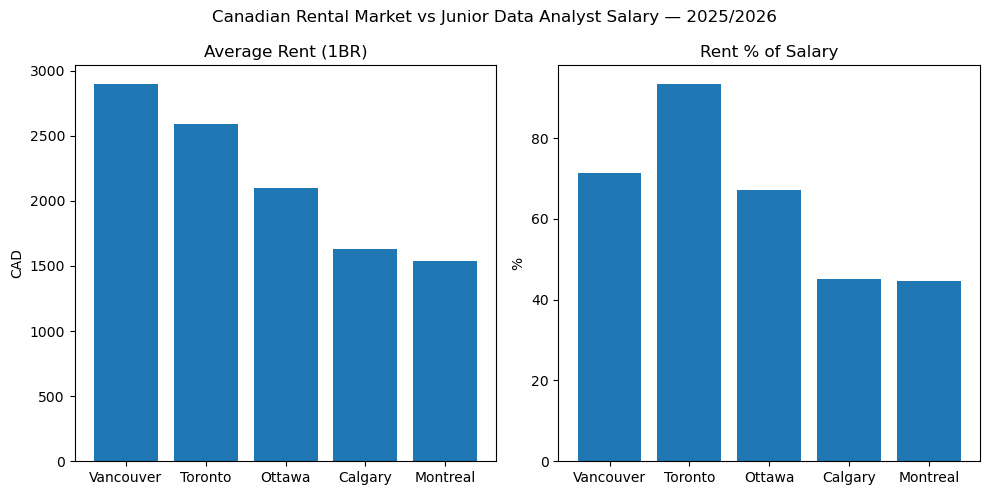

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

# Main title
plt.suptitle("Canadian Rental Market vs Junior Data Analyst Salary — 2025/2026")

# Rent chart
plt.subplot(1,2,1)
plt.bar(cities, rent)
plt.title("Average Rent (1BR)")
plt.ylabel("CAD")

# Rent % chart
plt.subplot(1,2,2)
plt.bar(cities, rent_percent)
plt.title("Rent % of Salary")
plt.ylabel("%")

plt.tight_layout()
plt.show()

In [25]:
##ADDING COLOURS & POLISHING

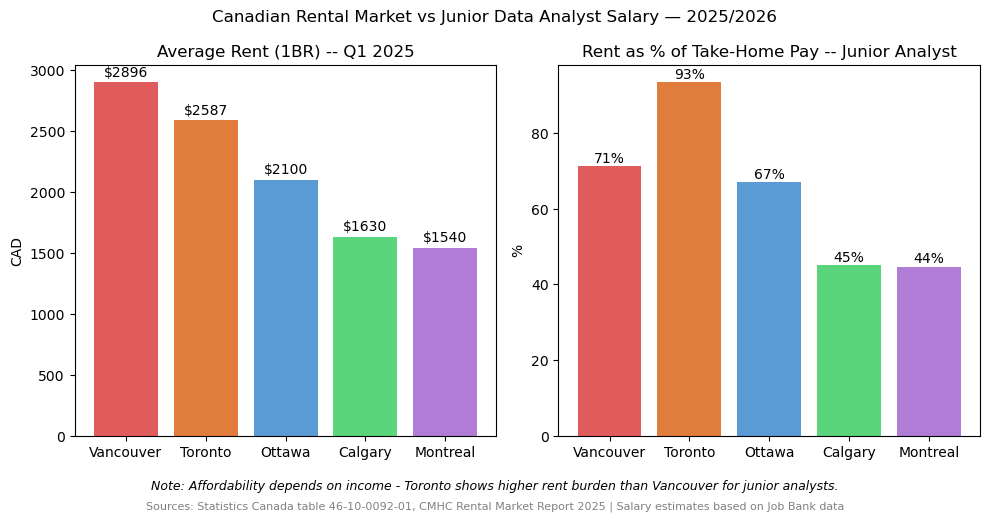

In [31]:
import matplotlib.pyplot as plt

colors = ['#e05c5c', '#e07c3c', '#5b9bd5', '#5bd57c', '#b07cd5']

plt.figure(figsize=(10,5))

# Main title
plt.suptitle("Canadian Rental Market vs Junior Data Analyst Salary — 2025/2026")

# Left Chart (Rent)
plt.subplot(1,2,1)
bars1 = plt.bar(cities, rent, color=colors)
plt.title("Average Rent (1BR) -- Q1 2025")
plt.ylabel("CAD")

# Add $ labels
for bar in bars1:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 50,
        f"${int(height)}",
        ha='center'
    )

#Right Chart (% Salary)
plt.subplot(1,2,2)
bars2 = plt.bar(cities, rent_percent, color=colors)
plt.title("Rent as % of Take-Home Pay -- Junior Analyst")
plt.ylabel("%")

# Add % labels
for bar in bars2:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{int(height)}%",
        ha='center'
    )

#Sources
# Insight line above sources
plt.figtext(
    0.5, 0.02, # Moved slightly up from -0.02 to ensure visibility
    "Note: Affordability depends on income - Toronto shows higher rent burden than Vancouver for junior analysts.",
    ha="center",
    fontsize=9,
    style='italic'
)

# Sources line
plt.figtext(
    0.5, -0.02, # Adjusted to sit just below the first note
    "Sources: Statistics Canada table 46-10-0092-01, CMHC Rental Market Report 2025 | Salary estimates based on Job Bank data",
    ha="center",
    fontsize=8,
    color='gray'
)

plt.tight_layout(rect=[0, 0.05, 1, 1])

# Save image
plt.savefig("rent_vs_salary.png", dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
# ----------------END-----------------